In [1]:
!pip install lightgbm shap

In [2]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import lightgbm as lgb
import joblib
import shap

/workspaces/Github_portfolio/.venv-train/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# --- 設定値 ---
# Kaggle「Students Performance in Exams」のCSVをここに配置してください
# https://www.kaggle.com/datasets/spscientist/students-performance-in-exams
CSV_PATH = "data/StudentsPerformance.csv"
MODEL_OUTPUT_DIR = "app/models/math_predictor/v1"

In [4]:
# --- ローカルCSVからデータを読み込む ---
df = pd.read_csv(CSV_PATH)

# 列名のスペースをアンダースコアに変換（race/ethnicityはスラッシュを維持）
df = df.rename(columns={
    "parental level of education": "parental_level_of_education",
    "test preparation course": "test_preparation_course",
    "math score": "math_score",
    "reading score": "reading_score",
    "writing score": "writing_score",
})

In [5]:
# --- 特徴量と目的変数を定義 ---
X = df.drop('math_score', axis=1)
y = df['math_score']

In [6]:
# --- データ分割 ---
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [7]:
# --- 前処理（One-Hot エンコーディング） ---
categorical_cols = X_train.select_dtypes(include=['object']).columns
X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)
final_columns = X_train_encoded.columns

/tmp/ipykernel_15966/679396815.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(include=['object']).columns


In [8]:
final_columns
results = {}
models = {}

In [9]:
# --- モデル学習と評価 ---
lr_model = LinearRegression()
lr_model.fit(X_train_encoded, y_train)
lr_pred = lr_model.predict(X_test_encoded)
results["LinearRegression"] = r2_score(y_test, lr_pred)
models["LinearRegression"] = lr_model

lgb_model = lgb.LGBMRegressor(random_state=42)
lgb_model.fit(X_train_encoded, y_train)
lgb_pred = lgb_model.predict(X_test_encoded)
results["LightGBM"] = r2_score(y_test, lgb_pred)
models["LightGBM"] = lgb_model

print("モデル比較結果:", results)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001039 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 151
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 14
[LightGBM] [Info] Start training from score 66.496250
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive ga

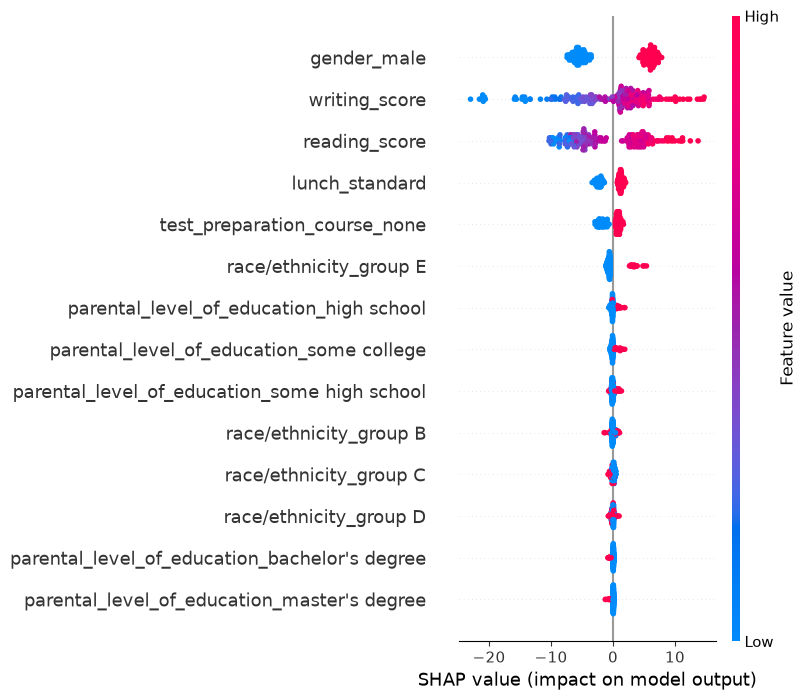

In [10]:
# --- SHAP値の計算 (LightGBM用) ---
explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer(X_test_encoded)
shap.summary_plot(shap_values, X_test_encoded, show=False)  # 可視化

In [11]:
# --- モデルと列情報をローカルに保存（appが読み込むディレクトリ） ---
os.makedirs(MODEL_OUTPUT_DIR, exist_ok=True)

for name, model in models.items():
    joblib.dump(model, os.path.join(MODEL_OUTPUT_DIR, f"{name}.pkl"))

joblib.dump(list(final_columns), os.path.join(MODEL_OUTPUT_DIR, "feature_list.pkl"))

print(f"モデルと特徴量リストを {MODEL_OUTPUT_DIR} に保存しました")

モデルと特徴量リストを app/models/math_predictor/v1 に保存しました
